In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def quadratic_loss(x, y):
    return x**2 + 10 * y**2

In [3]:
def quadratic_grad(x, y):
    dx = 2 * x
    dy = 20 * y
    return np.array([dx, dy])

In [4]:
def gradient_descent(grad_func, lr, epochs, start_point):
    x, y = start_point
    path = [(x, y)]
    losses = [quadratic_loss(x, y)]

    for _ in range(epochs):
        grad = grad_func(x, y)
        x -= lr * grad[0]
        y -= lr * grad[1]
        path.append((x, y))
        losses.append(quadratic_loss(x, y))

    return np.array(path), losses

In [5]:
def adam_optimizer(grad_func, lr, beta1, beta2, epsilon, epochs, start_point):
    x, y = start_point
    m = np.array([0.0, 0.0])
    v = np.array([0.0, 0.0])
    path = [(x, y)]
    losses = [quadratic_loss(x, y)]

    for t in range(1, epochs + 1):
        grad = grad_func(x, y)

        m = beta1 * m + (1 - beta1) * grad

        v = beta2 * v + (1 - beta2) * (grad ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        x -= lr * m_hat[0] / (np.sqrt(v_hat[0]) + epsilon)
        y -= lr * m_hat[1] / (np.sqrt(v_hat[1]) + epsilon)

        path.append((x, y))
        losses.append(quadratic_loss(x, y))

    return np.array(path), losses

In [6]:
def plot_paths(function, paths, labels, title):
    X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-2, 2, 400))
    Z = function(X, Y)

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, Z, levels=50, cmap='jet')

    for path, label in zip(paths, labels):
        plt.plot(path[:, 0], path[:, 1], label=label)
        plt.scatter(path[0, 0], path[0, 1], color='green', label="Start")
        plt.scatter(path[-1, 0], path[-1, 1], color='red', label="End")

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

In [7]:
def plot_losses(losses, labels, title):
    plt.figure(figsize=(8, 6))

    for loss, label in zip(losses, labels):
        plt.plot(loss, label=label)

    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [13]:
lr_gd = 0.1
lr_adam = 0.1
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
epochs = 550
start_point = (1.5, 1.5)

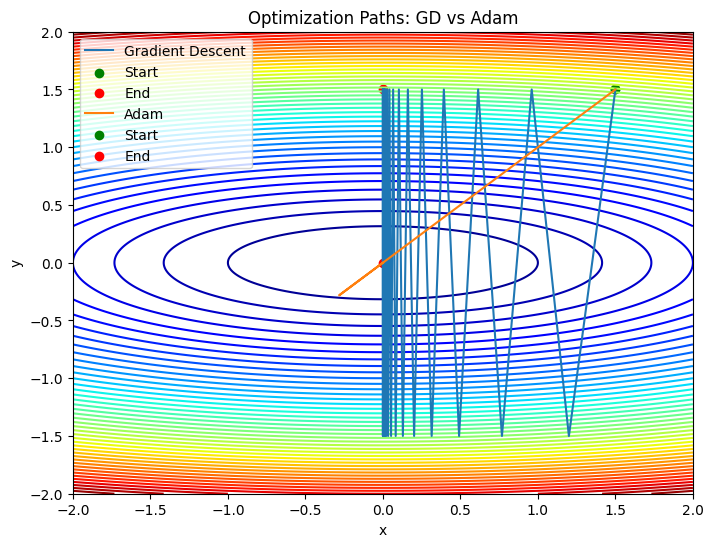

In [14]:
path_gd, losses_gd = gradient_descent(quadratic_grad, lr_gd, epochs, start_point)
path_adam, losses_adam = adam_optimizer(quadratic_grad, lr_adam, beta1, beta2, epsilon, epochs, start_point)
plot_paths(quadratic_loss, [path_gd, path_adam],
           ["Gradient Descent", "Adam"],
           "Optimization Paths: GD vs Adam")

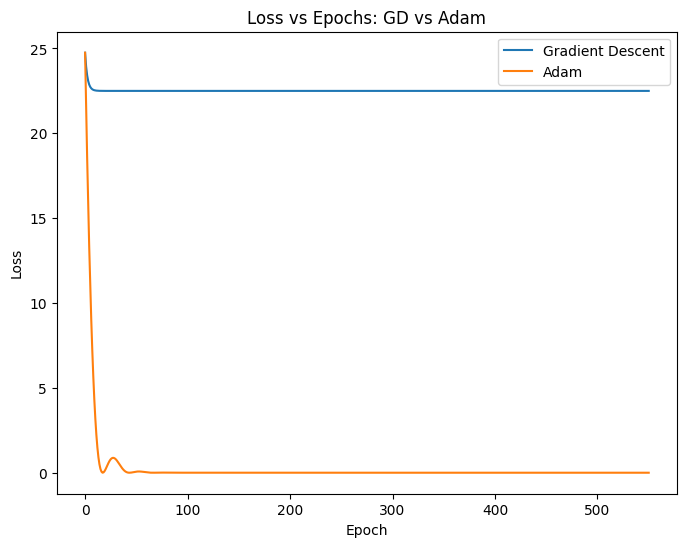

In [15]:
plot_losses([losses_gd, losses_adam],
            ["Gradient Descent", "Adam"],
            "Loss vs Epochs: GD vs Adam")